# <center>**LastFM Data Science Project**</center>

## **Import Libraries**

In [385]:
import pandas as pd
import numpy as np
import pylast

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from concurrent.futures import ThreadPoolExecutor, as_completed

from bs4 import BeautifulSoup
import requests

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("Note: umap-learn not installed. Run: pip install umap-learn")
    print("UMAP sections will be skipped.")

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# **Data Preparation**

## **Get API Access**

In [10]:
API_KEY = "2d901b318bd2a5c736ca66d22eadf0ae"
API_SECRET = "daa7b060a8bee7f17c7ba9f88d2f535f"
network = pylast.LastFMNetwork(
    api_key=API_KEY,
    api_secret=API_SECRET
)

# test connection
user = network.get_user('cosmeticstm')
print(user.get_name())

cosmeticstm


## **Get dynamic threshold for limit parameter**

In [12]:
def get_dynamic_threshold(user, fetch_limit=1000, percentile=75):
    '''
    Set threshold at the nth percentile of play counts
    '''
    import numpy as np
    
    top_artists = user.get_top_artists(limit=fetch_limit)
    play_counts = [int(a.weight) for a in top_artists]
    
    threshold = int(np.percentile(play_counts, percentile))
    print(f"Dynamic threshold ({percentile}th percentile): {threshold} plays")
    
    meaningful = [a for a in top_artists if int(a.weight) >= threshold]
    print(f"Artists above threshold: {len(meaningful)}")
    
    return meaningful

play_count = get_dynamic_threshold(user)

Dynamic threshold (75th percentile): 88 plays
Artists above threshold: 255


**Insights:**



## **Get top artists**

In [15]:
def fetch_artist_data(artist):
    '''Fetch data for a single artist, including tags.'''
    try:
        tags = artist.item.get_top_tags(limit=15) # set to any limit
        tag_names = [tag.item.name.lower() for tag in tags]
    except pylast.WSError as e:
        print(f"Could not fetch tags for '{artist.item.name}': {e}")
        tag_names = []

    return {
        'artist_name': artist.item.name,
        'play_count': int(artist.weight),
        'url': artist.item.get_url(),
        'tags': tag_names
    }

def parse_top_artists(top_artists, max_workers=10):
    '''
    Convert top artists to DataFrame format, including top tags.
    Fetches tags concurrently to reduce runtime.
    '''
    results = [None] * len(top_artists)  # preserve order

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_index = {
            executor.submit(fetch_artist_data, artist): i
            for i, artist in enumerate(top_artists)
        }
        for future in as_completed(future_to_index):
            i = future_to_index[future]
            results[i] = future.result()

    return pd.DataFrame(results)

# Usage
top_artists = user.get_top_artists(limit=len(play_count))
artists_df = parse_top_artists(top_artists, max_workers=10)
print(artists_df.head())
print(f'Dataframe Shape: {artists_df.shape}')

     artist_name  play_count                                         url  \
0     Kanye West        7070      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6400  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5850   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4577            https://www.last.fm/music/bladee   
4          Lucki        4206             https://www.last.fm/music/lucki   

                                                tags  
0  [hip-hop, rap, hip hop, rnb, kanye west, gay f...  
1  [trap, hip-hop, rap, emo rap, pop rap, hip hop...  
2  [trap, cloud rap, hip-hop, rap, rage, hip hop,...  
3  [cloud rap, trap, drain, hip-hop, hip hop, emo...  
4  [pop, dance, lucki, swedish, trap, female voca...  
Dataframe Shape: (255, 4)


# **Data Preprocessing**

## **Scrape list of valid tags / genres from MusicBrainz.org**

In [18]:
url = 'https://musicbrainz.org/genres' # URL to be scraped
page = requests.get(url) # use requests library

soup = BeautifulSoup(page.text, 'html') # use BS to read html

In [19]:
# remove comments from genres
for comment in soup.find_all('span', class_='comment'):
    comment.decompose()

genres = soup.find_all('bdi') # find all <bdi> tags 

valid_genres = set(genre.text.lower().strip() for genre in genres)

## **Filter valid genres with tags df** 

In [21]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag in valid_genres]
)
print(artists_df.head())

     artist_name  play_count                                         url  \
0     Kanye West        7070      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6400  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5850   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4577            https://www.last.fm/music/bladee   
4          Lucki        4206             https://www.last.fm/music/lucki   

                                            tags  
0                     [hip hop, pop, electronic]  
1   [trap, emo rap, pop rap, hip hop, cloud rap]  
2        [trap, cloud rap, rage, hip hop, plugg]  
3  [cloud rap, trap, hip hop, emo rap, hyperpop]  
4          [pop, dance, trap, techno, cloud rap]  


## **Check for null tags**

In [23]:
null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(null_tags)
print(f'\nNumber of null tags / genres: {num_null_tags}')

                     artist_name  play_count  \
82                alex_g_offline         347   
111               jaydes archive         273   
151                       yenny*         177   
165                 alexgoffline         161   
195               Ligaya Escueta         127   
220                     Kimaurii         105   
252  Lil Uzi Vert, Playboi Carti          88   

                                                   url tags  
82            https://www.last.fm/music/alex_g_offline   []  
111         https://www.last.fm/music/jaydes%2barchive   []  
151               https://www.last.fm/music/yenny%252a   []  
165             https://www.last.fm/music/alexgoffline   []  
195         https://www.last.fm/music/ligaya%2bescueta   []  
220                 https://www.last.fm/music/kimaurii   []  
252  https://www.last.fm/music/lil%2buzi%2bvert%252...   []  

Number of null tags / genres: 7


**Insights:**
- I decided to drop the 7 artists with null tags since `alex_g_offline`, `alexgoffline`, `jaydes archive`, and `yenny*` are unofficial archival accounts, not real artists
- `Ligaya Escueta` and `Kimaurii` are niche artists that didn't have any tag data, and thus won't contribute anything meaningfully to ML.
- `Lil Uzi Vert, Playboi Carti` are artifacts that came from Spotify Local Files scrobbling.

### **Prune null tags**

In [26]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (248, 4)


## **Check for sparse tags**

In [28]:
all_tags = [tag for tags in artists_df['tags'] for tag in tags] # Loops to find each tag in tags column

tag_series = pd.Series(all_tags) # Converts into series
tag_counts = tag_series.value_counts() # Counts how many times tag appears

sparse_tags = set(tag_counts[tag_counts < 5].index)
print(sparse_tags)

{'breakcore', 'post-grunge', 'death metal', 'dubstep', 'contemporary folk', 'stoner rock', 'jerk', 'industrial', 'blackgaze', 'free jazz', 'vaporwave', 'future bass', 'technical death metal', 'ghettotech', 'britpop', 'euro-trance', 'gothic', 'folk punk', 'noise rock', 'horror punk', 'electropop', 'baltimore club', 'progressive metal', 'crust punk', 'garage rock', 'electroclash', 'memphis rap', 'jangle pop', 'j-pop', 'americana', 'jump up', 'heavy metal', 'gospel', 'trap metal', 'french house', 'sigilkore', 'funk rock', 'witch house', 'piano rock', 'math pop', 'ghetto house', 'new rave', 'wave', 'goa trance', 'geek rock', 'dark plugg', 'dance', 'tarantella', 'chillwave', 'skate punk', 'jazz pop', 'space rock', 'east coast hip hop', 'drum and bass', 'classic rock', 'drill', 'avant-garde jazz', 'rapcore', 'drone', 'grindcore', 'neo-psychedelia', 'jazz rap', 'electro', 'nightcore', 'shibuya-kei', 'sound collage', 'west coast hip hop', 'chamber pop', 'regalia', 'uk hardcore', 'soft rock', '

### **Remove sparse tags and check null tags**

In [30]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag not in sparse_tags]
) # Checks if tag is not in sparse_tags

print(artists_df[artists_df['tags'].apply(len) == 0]) # Checks artists with null tags

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')

    artist_name  play_count                             url tags
210        Yuke         110  https://www.last.fm/music/yuke   []
Number of null tags / genres: 1


### **Remove null tags**

In [32]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {len(null_tags)}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (247, 4)


## **Feature Engineering**

In [34]:
mlb = MultiLabelBinarizer()
ohe = pd.DataFrame(
    mlb.fit_transform(artists_df['tags']),
    columns=mlb.classes_,
    index=artists_df.index
)

final_df = pd.concat([artists_df, ohe], axis=1)
final_df = final_df.drop('tags', axis=1)
print(f'Final Dataframe Shape: {final_df.shape}')
print(f'Columns:\n{final_df.columns}')

Final Dataframe Shape: (247, 57)
Columns:
Index(['artist_name', 'play_count', 'url', 'alternative metal',
       'alternative rock', 'ambient', 'art pop', 'bedroom pop', 'cloud rap',
       'dream pop', 'electronic', 'emo', 'emo rap', 'emocore', 'experimental',
       'experimental hip hop', 'folk', 'funk', 'gangsta rap', 'grunge',
       'hard rock', 'hardcore punk', 'hip hop', 'horrorcore', 'indie folk',
       'indie pop', 'indie rock', 'lo-fi', 'math rock', 'melodic hardcore',
       'metal', 'metalcore', 'midwest emo', 'noise pop', 'nu metal', 'plugg',
       'pluggnb', 'pop', 'pop punk', 'pop rap', 'pop rock', 'post-hardcore',
       'post-punk', 'post-rock', 'psychedelic', 'punk', 'punk rock', 'rage',
       'rock', 'screamo', 'shoegaze', 'singer-songwriter', 'slacker rock',
       'slowcore', 'soul', 'southern hip hop', 'trap'],
      dtype='str')


# **Exploratory Data Analysis (EDA)**

## **Play Count Distribution**

=== Descriptive Statistics ===
Total artists: 247
Max plays: 7070
Min plays: 88
Median plays: 233
Mean plays: 528.12
Std dev: 907.33


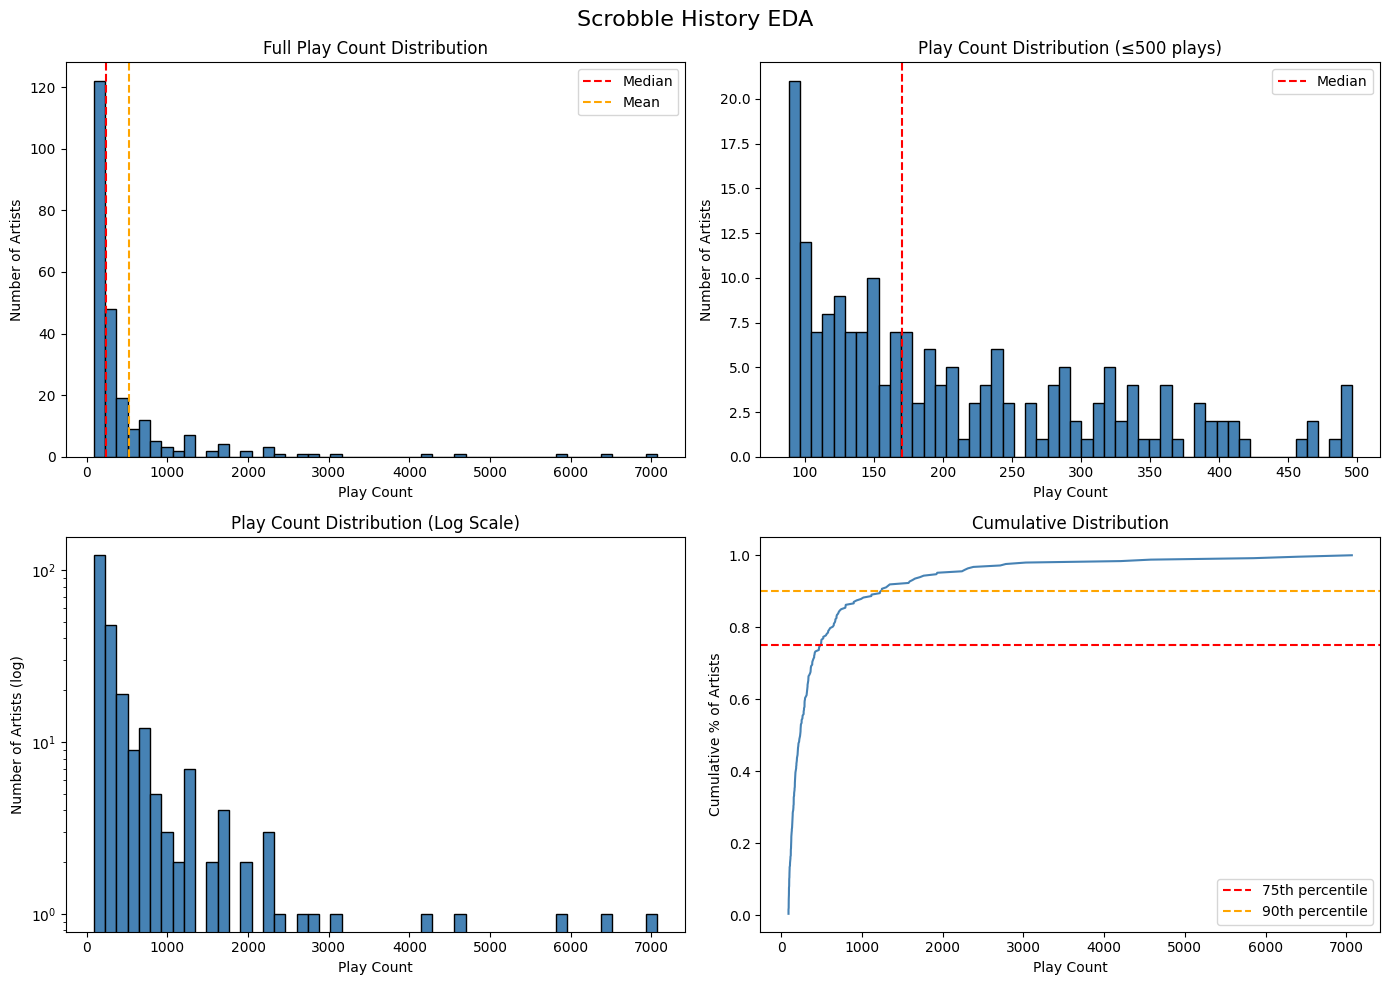

Total artists that exceed 1000: 30


In [37]:
play_counts = artists_df['play_count'].tolist()

# Basic stats
print("=== Descriptive Statistics ===")
print(f"Total artists: {len(play_counts)}")
print(f"Max plays: {max(play_counts)}")
print(f"Min plays: {min(play_counts)}")
print(f"Median plays: {int(np.median(play_counts))}")
print(f"Mean plays: {np.mean(play_counts):.2f}")
print(f"Std dev: {np.std(play_counts):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scrobble History EDA', fontsize=16)

# 1. Full distribution
axes[0,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Full Play Count Distribution')
axes[0,0].set_xlabel('Play Count')
axes[0,0].set_ylabel('Number of Artists')
axes[0,0].axvline(np.median(play_counts), color='red', linestyle='--', label='Median')
axes[0,0].axvline(np.mean(play_counts), color='orange', linestyle='--', label='Mean')
axes[0,0].legend()

# 2. Zoomed in
zoomed = [p for p in play_counts if p <= 500]
axes[0,1].hist(zoomed, bins=50, color='steelblue', edgecolor='black')
axes[0,1].set_title('Play Count Distribution (≤500 plays)')
axes[0,1].set_xlabel('Play Count')
axes[0,1].set_ylabel('Number of Artists')
axes[0,1].axvline(np.median(zoomed), color='red', linestyle='--', label='Median')
axes[0,1].legend()

# 3. Log scale distribution
axes[1,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black', log=True)
axes[1,0].set_title('Play Count Distribution (Log Scale)')
axes[1,0].set_xlabel('Play Count')
axes[1,0].set_ylabel('Number of Artists (log)')

# 4. Cumulative distribution
sorted_counts = np.sort(play_counts)
cumulative = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1,1].plot(sorted_counts, cumulative, color='steelblue')
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('Play Count')
axes[1,1].set_ylabel('Cumulative % of Artists')
axes[1,1].axhline(0.75, color='red', linestyle='--', label='75th percentile')
axes[1,1].axhline(0.90, color='orange', linestyle='--', label='90th percentile')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'Total artists that exceed 1000: {(artists_df['play_count'] > 1000).sum()}')  # how many exceed 1000

**Insights:**
- The play count distribution shows that scrobbles (aka plays / listens) are heavily right-skewed, meaning a large majority of artists recorded in my LastFM listening history have less than ~1000 total listens.
    - The mean and median of play counts further show that a large portion of the artists is densely focused between the <1000 listens area which further confirm my hypothesis.
    - For a listening distribtion, this is normal since only a few artists would tend to be listened to repeatedly (hardcore faves), while a majority of other artists would have listens on the smaller end (casual - occasional listens).
- Zoomed in play count distribution shows that most artists only have ~100 total artists, slowly tapering off until the 500 total listens mark.
    -   Artists with $\small \leq$100 listens can be classified as 'accidental' listens
- Based on the log scaled distribution, artists that have more than 1000 total listens are sparse in the dataset.
    - The cumulative distribution indicates that 75% of artists have less than 1000 listens (~185 artists) while 90% of artists have less than ~1500 listens (~222 artists).

## **Tag / Genre Distribution**

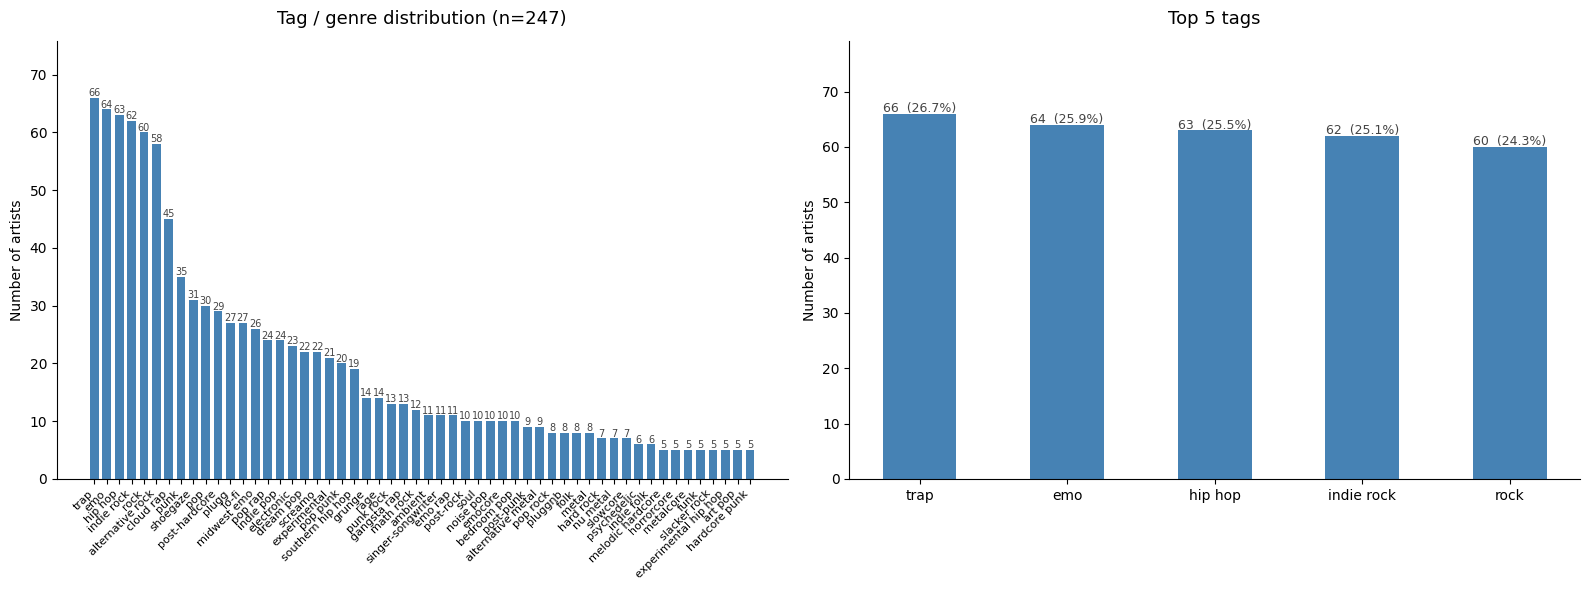

Top 5 exclusively indie rock artists by play count:
    artist_name  play_count
   wifiskeleton        1576
         Alex G        1244
Modern Baseball        1016
       Panchiko         798
       Marietta         710
Top 5 exclusively rock artists by play count:
                artist_name  play_count
                   Deftones        2713
                     Jaydes        2379
                    Nirvana        1625
        My Chemical Romance        1117
i wanna be a jack-o-lantern         561


In [40]:
tag_cols = final_df.columns.difference(['artist_name', 'play_count', 'url']).tolist()
tag_counts = final_df[tag_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# full distribution
bars = axes[0].bar(tag_counts.index, tag_counts.values, color='steelblue', edgecolor='none', width=0.7)
for bar, val in zip(bars, tag_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 str(val), ha='center', fontsize=7, color='#444')
axes[0].set_ylabel('Number of artists')
axes[0].set_title(f'Tag / genre distribution (n={len(final_df)})', fontsize=13, pad=12)
axes[0].set_xticks(range(len(tag_counts)))
axes[0].set_xticklabels(tag_counts.index, rotation=45, ha='right', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, tag_counts.max() * 1.15)

# top 5
top5 = tag_counts.head(5)
bars2 = axes[1].bar(top5.index, top5.values, color='steelblue', edgecolor='none', width=0.5)
for bar, val in zip(bars2, top5.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f'{val}  ({val / len(final_df) * 100:.1f}%)',
                 ha='center', fontsize=9, color='#444')
axes[1].set_ylabel('Number of artists')
axes[1].set_title('Top 5 tags', fontsize=13, pad=12)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, top5.max() * 1.2)

plt.tight_layout()
plt.show()

# indie rock vs. rock genre
print('=' * 50)
print("Top 5 exclusively indie rock artists by play count:")
print(final_df[(final_df['indie rock'] == 1) & (final_df['rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

print('=' * 50)
print("Top 5 exclusively rock artists by play count:")
print(final_df[(final_df['rock'] == 1) & (final_df['indie rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

**Insights:**

- The genre distribution is heavily right skewed, with a set of 'broader' genres such as `trap`, `emo`, `hip hop`, `indie rock` and `rock` dominating.
- Genres such as `trap`, `emo`, and `indie rock` in LastFM aren't necessarily categorized as a more 'specific' genre / subgenre per se, nor are they necessarily part of any real hierarchy of genres or subgenres (i.e rock -> indie rock or hip hop -> trap).
    - In the case of `emo`, the genre has both been used to refer to both the original indie/punk subculture (Cap'n Jazz, Sunny Day Real Estate) and to the contemporary label applied to emotionally raw artists across hip hop, pop punk, and other genres (Lil Uzi Vert, Paramore, Panic! At The Disco).
    - Similarly, users most likely felt the `indie rock` tag to be a more apt description of artists that are closer both to independently produced music (Alex G, Panchiko) as well as the indie aesthetic (wifiskeleton) over the `rock` tag which usually implies mainstream acts such as Deftones, My Chemical Romance and Nirvana.
        - Worth noting is that the tags system is based on user-driven inputs, and then subsequently aggregated and weighted by how many users applied them.
        - As a result, tagging becomes inconsistent with heavy recency bias, prioritizing overall cultural consensus over accuracy (i.e Nirvana not being `indie rock` despite independent roots), and obscure artists resulting in a less reliable classified genre (i.e Jaydes and i wanna be a jack-o-lantern as `rock`).

## **Tag Count Per Artist**

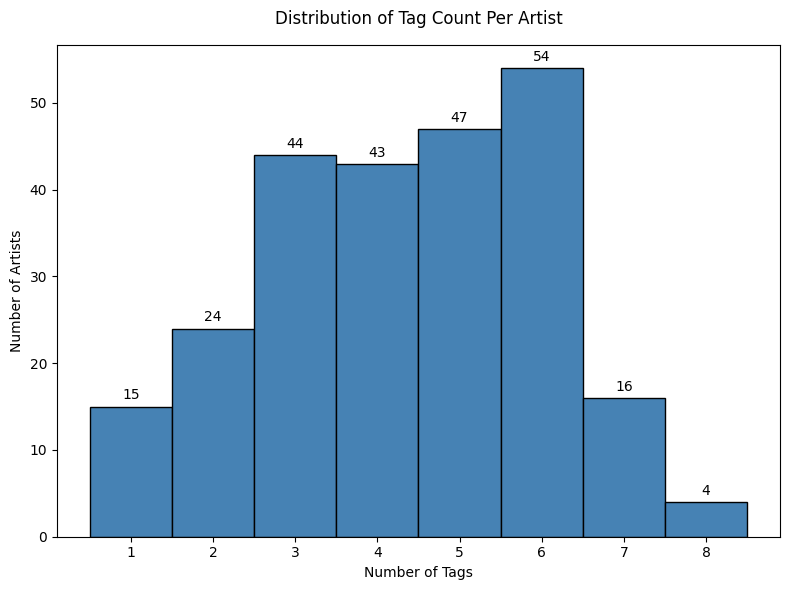

Mean Tag Count per Artist: 4.33
List of Artists with One Tag:
   artist_name         tags
Kendrick Lamar    [hip hop]
    Steve Lacy       [soul]
          Lamp  [indie pop]
       MF DOOM    [hip hop]
       Fulcrum      [plugg]
      DECALIUS      [metal]
       Takeoff       [trap]
       J. Cole    [hip hop]
         Nunya       [punk]
      NewJeans        [pop]
   LE SSERAFIM        [pop]
   Joey Bada$$    [hip hop]
Snow Strippers [electronic]
          imsg      [plugg]
         evvls        [emo]


In [362]:
tag_counts = artists_df['tags'].str.len()

fig, ax = plt.subplots(figsize=(8, 6))

# Define explicit integer bin edges from 1 to max+1
# This ensures each bar represents exactly ONE integer
bins = np.arange(1, max(tag_counts) + 2)

counts, edges, bars = ax.hist(tag_counts, bins=bins, color='steelblue', edgecolor='black', align='left')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Distribution of Tag Count Per Artist', pad=15)
ax.set_xlabel('Number of Tags')
ax.set_ylabel('Number of Artists')

# Explicitly set x-ticks to show every integer perfectly
ax.set_xticks(range(1, max(tag_counts) + 1))

plt.tight_layout()
plt.show()

print(f'Mean Tag Count per Artist: {tag_counts.mean().round(2)}')
# Check artists with one tag
artists_df['tag_count'] = artists_df['tags'].apply(len)

print('=' * 50, '\nList of Artists with One Tag:')
print(artists_df[artists_df['tag_count'] <= 1][['artist_name', 'tags']].to_string(index=False))

**Insights:**
- Based on the distribution, on average, each artist at least has 4.33 valid tags / genres applied to their LastFM artist page.
- 15 artists out of 247 (6%) have only one tag even after increasing tag limit to 15.
    - This is mainly due to removing sparse tags in the dataset which led these artists to only have one genre of which they represent the most.
    - Removing these artists may result in further data loss, so they stay as edge cases

## **Genre Correlation Heatmap**

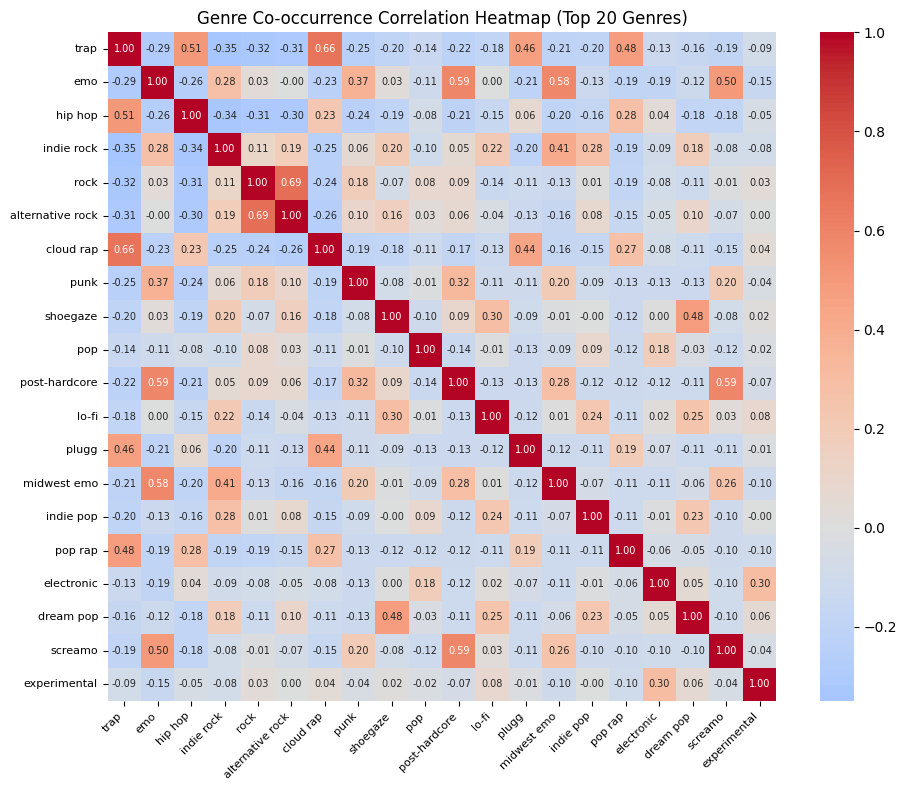

Strongest Correlations (co-occur frequently)
         genre_1       genre_2  correlation
alternative rock          rock     0.688443
       cloud rap          trap     0.663109
   post-hardcore       screamo     0.592410
             emo post-hardcore     0.588041
             emo   midwest emo     0.579997
         hip hop          trap     0.507237
             emo       screamo     0.496317
       dream pop      shoegaze     0.482180
         pop rap          trap     0.481495
           plugg          trap     0.462859
Weakest Correlations (rarely appear together)
         genre_1    genre_2  correlation
      indie rock       trap    -0.349577
         hip hop indie rock    -0.338744
            rock       trap    -0.320714
alternative rock       trap    -0.312931
         hip hop       rock    -0.309790
alternative rock    hip hop    -0.302237
             emo       trap    -0.294460
alternative rock  cloud rap    -0.261465
             emo    hip hop    -0.261246
       cloud ra

In [235]:
# get only the OHE columns
ohe_cols = mlb.classes_
ohe_df = final_df[ohe_cols]

# correlation matrix
top_genres = ohe_df.sum().nlargest(20).index
corr_matrix = ohe_df[top_genres].corr()

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 7},
    square=True
)
plt.title('Genre Co-occurrence Correlation Heatmap (Top 20 Genres)', fontsize=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# find strongly correlated genre pairs
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation

# remove duplicates (A-B and B-A are the same pair)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# reset index and rename columns
corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ['genre_1', 'genre_2', 'correlation']

strong_positive = corr_pairs[corr_pairs['correlation'] > 0.3].sort_values('correlation', ascending=False)
strong_negative = corr_pairs[corr_pairs['correlation'] < -0.1].sort_values('correlation')

print("=" * 50, "\nStrongest Correlations (co-occur frequently)")
print(strong_positive.head(10).to_string(index=False))

print("=" * 50, "\nWeakest Correlations (rarely appear together)")
print(strong_negative.head(10).to_string(index=False))

**Insights:**
- Based on the correlation heatmap matrix, the strongest correlations are the genres that both make sense sonically and are commonly paired together (`cloud rap` - `trap`, `emo` - `midwest emo`, `dream pop` - `shoegaze`).
- On the other hand, the weakest correlations are the genres that rarely appear together, whether it may be through it being a niche pairing or generally not making sense sonically (`indie rock` - `trap`, `rock` - `trap`, `cloud rap` - `indie rock`).

# **Data Modeling**

## **K-Means Clustering**

### **Feature Selection and Scaling**

#### **TF-IDF**

**Problem**: Artists are frequently tagged with broad genres such as `hip hop`, `rock`, `emo`, where it leads to these generalized broad genres simply just dominating everything telling us literally nothing about our actual music taste. Every artist becomes similar to each other simply because they have some combination of the same genres.

**Solution**: Utilize Term Frequency-Inverse Document Frequency (TF-IDF), penalizing tags that are broad and frequently appear everywhere by downweighting them and rewarding tags that are rarer and more specific. This makes it so that when we cluster, it's not necessarily just `hip hop` vs. `rock` vs. `emo`, it becomes more niche-driven and specific.

In [271]:
# Joins tags list into a single string per artist
tags_joined = artists_df['tags'].apply(
    lambda x: ' '.join([tag.replace('-', '_').replace(' ', '_') for tag in x]) 
    if isinstance(x, list) else ''
)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(tags_joined)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=tfidf.get_feature_names_out(),
    index=[f'Doc{i+1}' for i in range(len(tags_joined))]
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"Unique tags: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape: (247, 54)
Unique tags: 54


### **Find Optimal K**

#### **Elbow Analysis & Newton-Raphson**

In [288]:
K_range = range(1, 11)
wcss = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    km.fit(tfidf_matrix)
    wcss.append(km.inertia_)

# Discrete first and second differences
ks  = np.array(list(K_range), dtype=float)
ws  = np.array(wcss, dtype=float)
d1  = np.diff(ws)        # ΔInertia  ≈ f'(K)
d2  = np.diff(d1)        # ΔΔInertia ≈ f''(K)
ks2 = ks[1:-1]           # K values aligned with d2

# Print elbow table
print("--- Elbow Analysis ---")
print(f"{'K':<6}{'WCSS':<12}{'ΔInertia':>12}{'ΔΔInertia':>12}")
print("-" * 44)
for i, (k, w) in enumerate(zip(ks, ws)):
    d1_str = f"{d1[i-1]:>12.2f}" if i >= 1 else f"{'—':>12}"
    d2_str = f"{d2[i-2]:>12.2f}" if i >= 2 else f"{'—':>12}"
    print(f"  {int(k):<6}{w:<12.2f}{d1_str}{d2_str}")

# Fit quadratic to ΔΔInertia and run Newton-Raphson
coeffs = np.polyfit(ks2, d2, 2)
p      = np.poly1d(coeffs)
dp     = p.deriv()

print("\n--- Newton-Raphson Iterations (finding root of ΔΔInertia fit) ---")
print(f"{'n':<6}{'Kₙ':<12}{'p(Kₙ)':<14}{'p′(Kₙ)':<14}{'Kₙ₊₁':<12}{'|ΔK|'}")
print("-" * 62)

K = float(ks2.mean())
for i in range(50):
    pk    = p(K)
    dpk   = dp(K)
    if abs(dpk) < 1e-12:
        break
    K_new = K - pk / dpk
    delta = abs(K_new - K)
    print(f"  {i:<6}{K:<12.4f}{pk:<14.4f}{dpk:<14.4f}{K_new:<12.4f}{delta:.6f}")
    K = K_new
    if delta < 1e-6:
        break

optimal_k = int(round(np.clip(K, ks[0], ks[-1])))
print(f"\nNewton-Raphson converged at K* = {K:.4f}  →  Optimal K = {optimal_k}")

--- Elbow Analysis ---
K     WCSS            ΔInertia   ΔΔInertia
--------------------------------------------
  1     219.36                 —           —
  2     194.33            -25.03           —
  3     181.05            -13.28       11.75
  4     171.82             -9.24        4.04
  5     163.45             -8.37        0.87
  6     156.24             -7.21        1.16
  7     151.07             -5.17        2.03
  8     143.78             -7.29       -2.11
  9     139.34             -4.44        2.85
  10    135.22             -4.13        0.31

--- Newton-Raphson Iterations (finding root of ΔΔInertia fit) ---
n     Kₙ          p(Kₙ)         p′(Kₙ)        Kₙ₊₁        |ΔK|
--------------------------------------------------------------
  0     5.5000      0.1424        -1.1202       5.6271      0.127150
  1     5.6271      0.0076        -1.0006       5.6348      0.007601
  2     5.6348      0.0000        -0.9935       5.6348      0.000027
  3     5.6348      0.0000        -0.99

Mathematical Elbow detected at K = 6


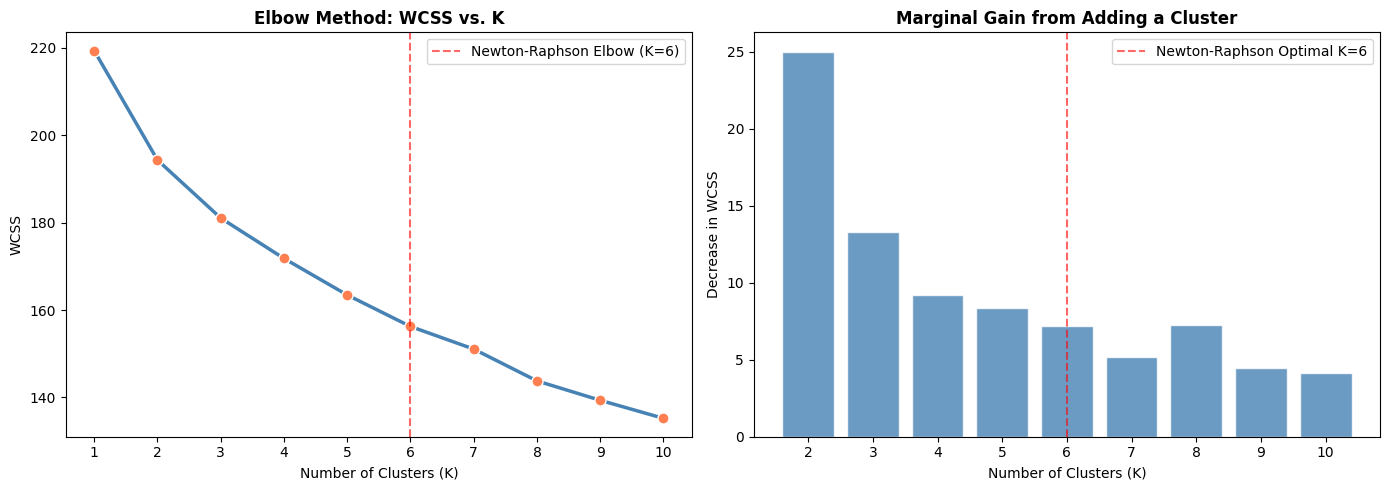

In [290]:
print(f"Mathematical Elbow detected at K = {optimal_k}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Elbow Curve ---
ax1.plot(list(K_range), wcss, marker='o', color='steelblue', linewidth=2.5,
         markersize=8, markerfacecolor='coral', markeredgecolor='white')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method: WCSS vs. K', fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6,
            label=f'Newton-Raphson Elbow (K={optimal_k})')
ax1.legend()

# --- Right Plot: Marginal Decrease ---
delta_wcss = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
k_labels = list(range(2, len(list(K_range)) + 1))
ax2.bar(k_labels, delta_wcss, color='steelblue', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Decrease in WCSS')
ax2.set_title('Marginal Gain from Adding a Cluster', fontweight='bold')
ax2.set_xticks(k_labels)
ax2.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6,
            label=f'Newton-Raphson Optimal K={optimal_k}')
ax2.legend()

plt.tight_layout()
plt.show()

#### **Silhouette Scores in finding K**

Silhouette Analysis:
----------------------------------------
    K  |   Mean Silhouette Score
----------------------------------------
  K=2  |                  0.1125
  K=3  |                  0.1183
  K=4  |                  0.1249
  K=5  |                  0.1289
  K=6  |                  0.1206
  K=7  |                  0.1176
----------------------------------------


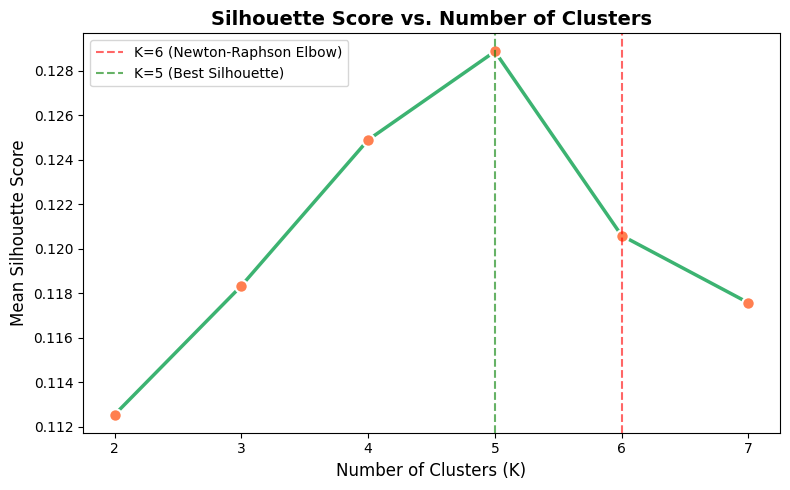


Best K by silhouette score: K=5 (score = 0.1289)


In [304]:
K_test = range(2, 8)
silhouette_scores = []

print("Silhouette Analysis:")
print("-" * 40)
print(f"{'K':>5}  |  {'Mean Silhouette Score':>22}")
print("-" * 40)

for k in K_test:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append(score)
    print(f"  K={k}  |  {score:>22.4f}")

print("-" * 40)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(K_test), silhouette_scores, marker='o', color='mediumseagreen', linewidth=2.5,
         markersize=9, markerfacecolor='coral', markeredgecolor='white', markeredgewidth=1.5)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Mean Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=14, fontweight='bold')
plt.xticks(list(K_test))
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6, 
            label=f'K={optimal_k} (Newton-Raphson Elbow)')
best_k = list(K_test)[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.6, 
            label=f'K={best_k} (Best Silhouette)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: K={best_k} (score = {max(silhouette_scores):.4f})")

optimal_k = 5

**Insights:**

- Moving forward, I will be utilizing K=5. This is due to silhouette score rapidly dropping at K=6, while it is at its highest at K=5
- The $\small{\triangle \triangle}$Inertia is at its lowest at K=5 compared to K=6 where it actually rose.
- Looking closer at Newton-Raphson method, K converged at 5.63 but rounded up to 6, which means it's closer to K=5 than it appears.

### **Silhouette Plot Comparison**

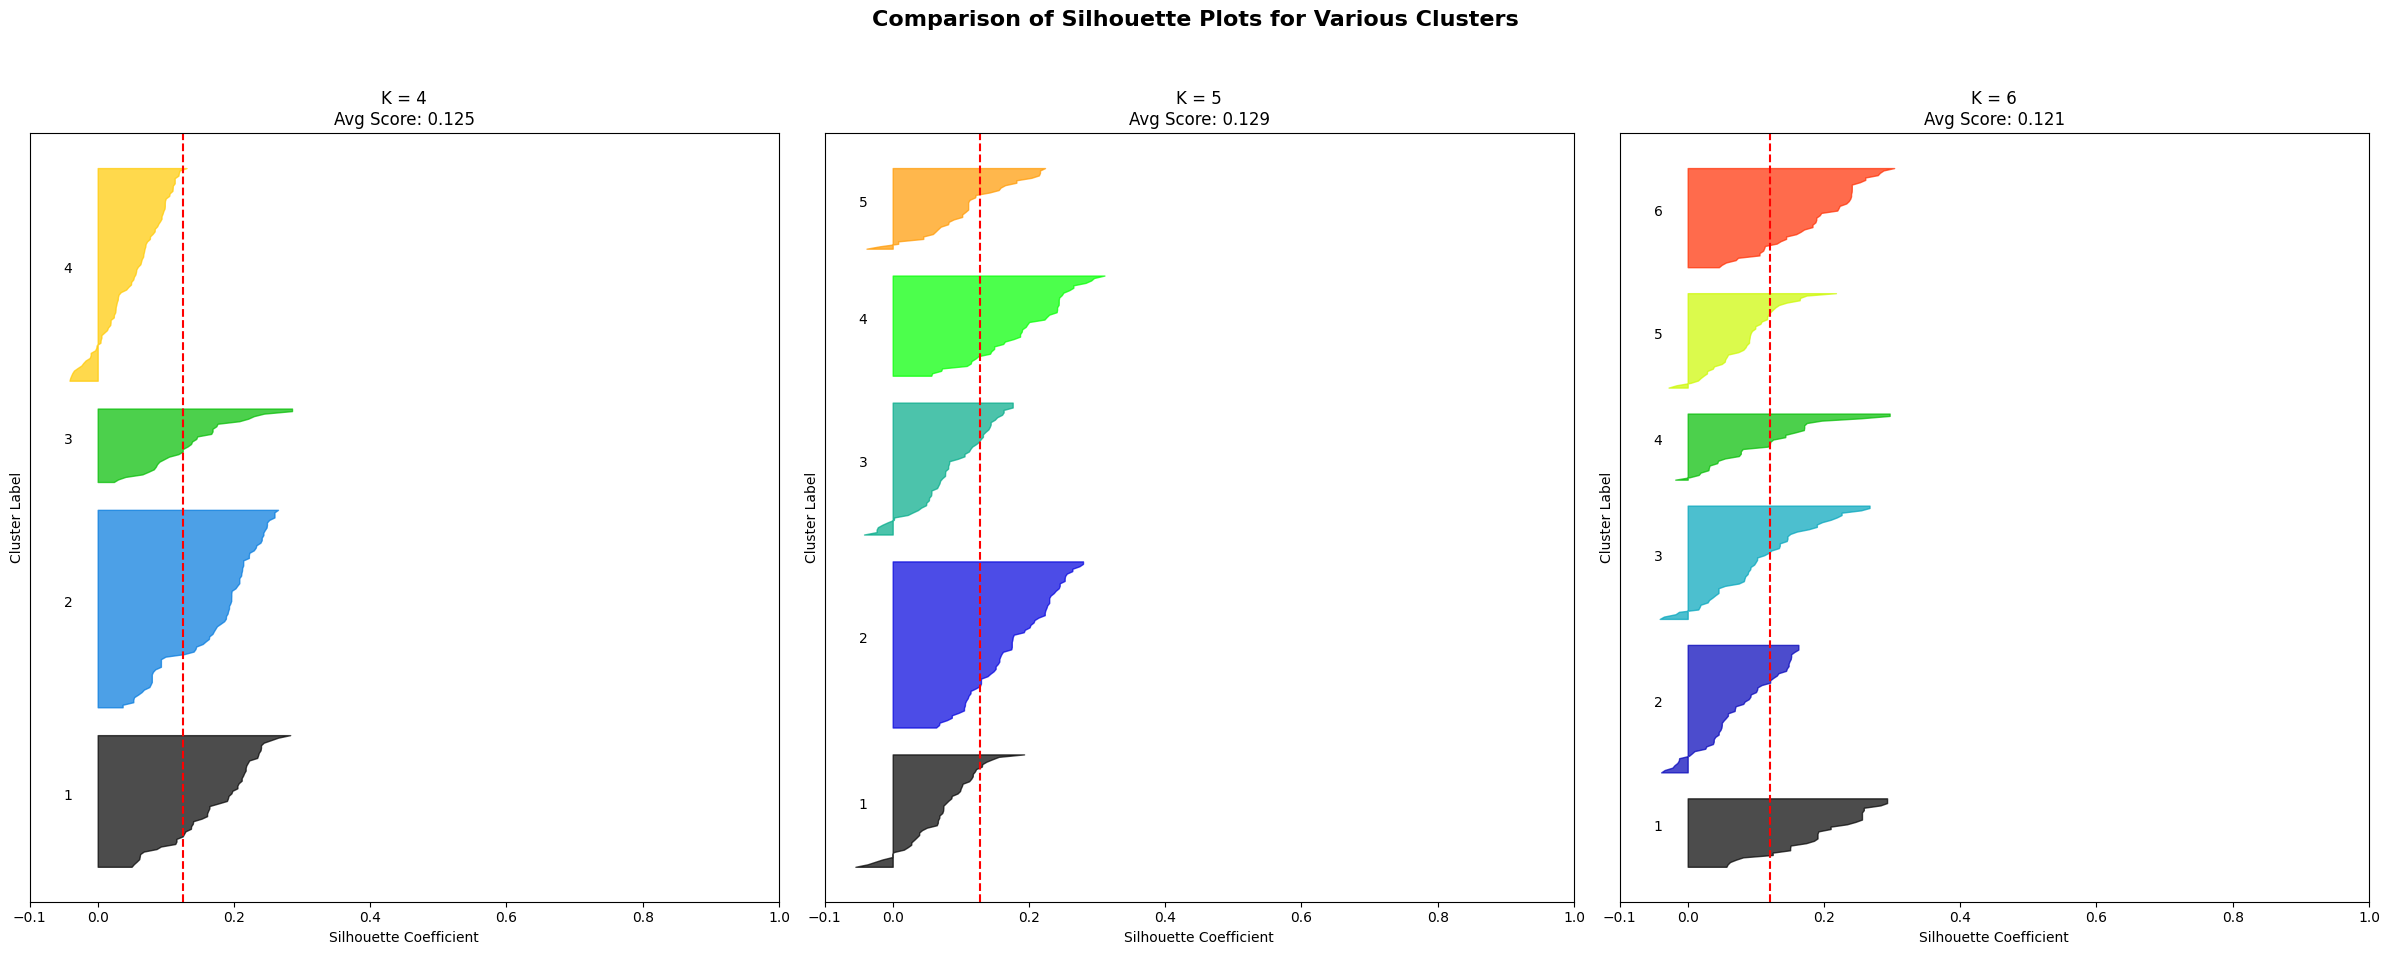

In [323]:
# Compare K values around our optimal
range_n_clusters = [4, 5, 6]

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(tfidf_matrix)

# Create a figure with subplots (1 row, multiple columns)
fig, axes = plt.subplots(1, len(range_n_clusters), figsize=(24, 10))

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axes[idx]
    
    # Initialize and fit KMeans
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(tfidf_matrix)
    
    # Calculate scores
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    sample_silhouette_values = silhouette_samples(tfidf_matrix, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
        y_lower = y_upper + 10

    ax.set_title(f"K = {n_clusters}\nAvg Score: {silhouette_avg:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle("Comparison of Silhouette Plots for Various Clusters", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insights:**

- Looking at each silhouette plot, the clear-cut best K would still be ``K=5``
- While ``K=4`` has the least amount of clusters, both gray and blue clusters dominate and are too wide leading to the yellow cluster falling short.
- ``K=5`` has the most even and balanced distribution out of all three plots. Clusters 2-4 are relatively even, where all clusters are past the average line.
- For ``K=6``, the clusters are too fragmented, suggesting that it leads to over-splitting of coherent genre groups.

## **Fit Final K-means Model**

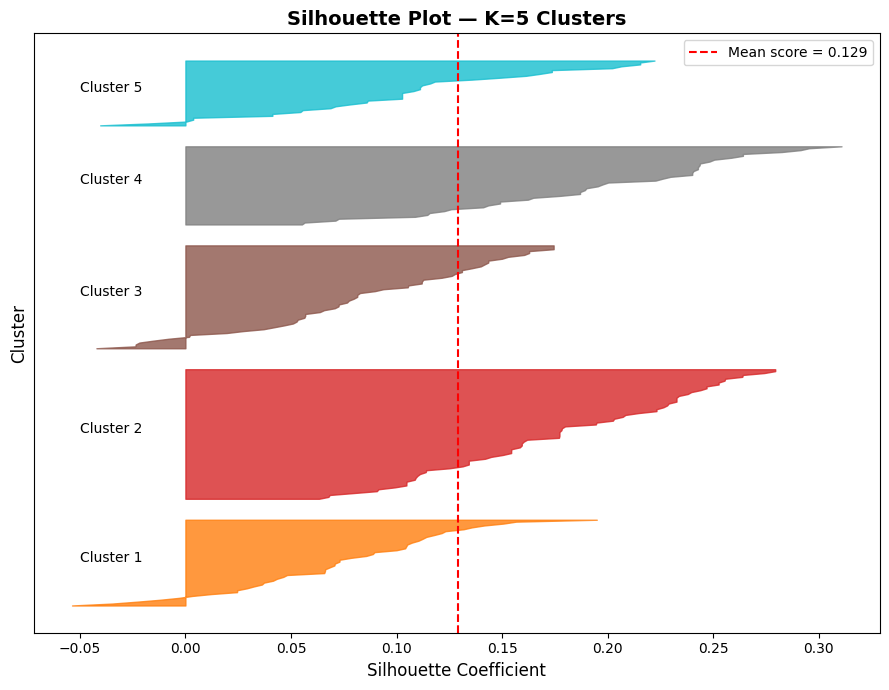

Silhouette Score: 0.1289
Davies-Bouldin Index: 2.5536
Calinski-Harabasz Index: 20.6764


In [351]:
K_final = 5
km_final = KMeans(n_clusters=K_final, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(tfidf_df)

silhouette_vals = silhouette_samples(tfidf_df, labels_final)
avg_score = silhouette_score(tfidf_df, labels_final)

s_score_k = silhouette_score(tfidf_df, labels_final)
db_index_k = davies_bouldin_score(tfidf_df, labels_final)
ch_index_k = calinski_harabasz_score(tfidf_df, labels_final)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
colors = cm.tab10(np.linspace(0.1, 0.9, K_final))

for i in range(K_final):
    cluster_sil_vals = silhouette_vals[labels_final == i]
    cluster_sil_vals.sort()
    cluster_size = len(cluster_sil_vals)
    y_upper = y_lower + cluster_size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, f'Cluster {i+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean score = {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot — K={K_final} Clusters', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Silhouette Score: {s_score_k:.4f}")
print(f"Davies-Bouldin Index: {db_index_k:.4f}")
print(f"Calinski-Harabasz Index: {ch_index_k:.4f}")

**Insights:**

## **Dimensionality Reduction**
- **Problem:** Since our TF-IDF dataframe contains 57 columns / dimensions, I'll need to be able to project the high-dimensionality of each genre to a 2-dimensional space in order to fully prepare, capture and visualize the clusters without removing any features.
- **Solution:** Utilize PCA & UMAP as dimensionality reduction methods.

### **PCA**

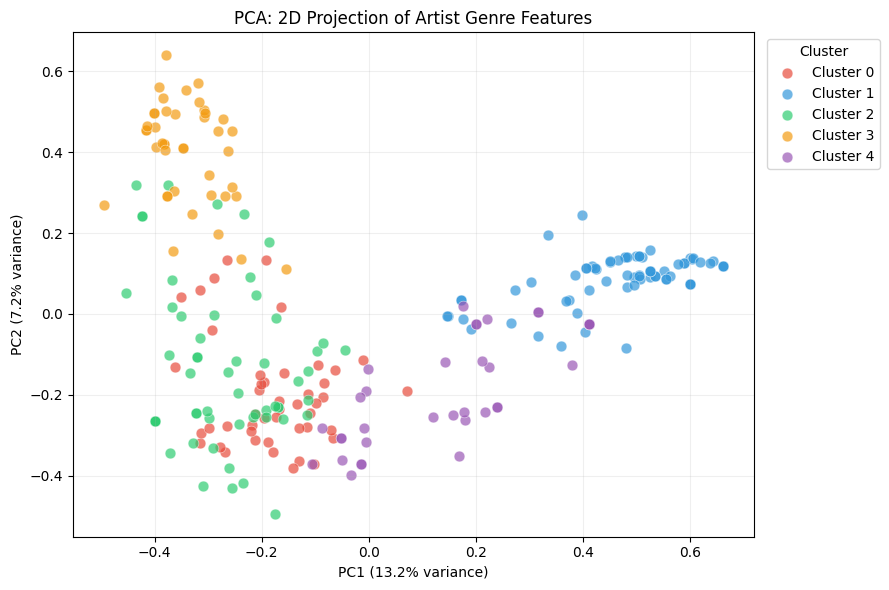

PCA 2D PROJECTION SUMMARY
  PC1 explains: 13.20% of variance
  PC2 explains: 7.23% of variance
  Combined:     20.43%

Top 5 genres contributing most to PC1 (by absolute loading):
  +0.448  trap
  +0.434  hip_hop
  +0.318  cloud_rap
  -0.246  indie_rock
  -0.239  emo

Top 5 genres contributing most to PC2 (by absolute loading):
  +0.441  emo
  +0.329  midwest_emo
  +0.292  screamo
  +0.278  post_hardcore
  -0.267  pop



In [441]:
# Project onto first two PCs (visualization)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(tfidf_df)

# Project onto first ten PCs (downstream use e.g. UMAP, KMeans input)
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(tfidf_df)

# Extract cluster labels from fitted KMeans model
cluster_labels = km_final.labels_

assert len(cluster_labels) == len(tfidf_df), (
    f"Mismatch: cluster_labels has {len(cluster_labels)} labels, tfidf_df has {len(tfidf_df)} rows"
)

n_clusters = len(np.unique(cluster_labels))
colors = {
    0: '#e74c3c',  # red
    1: '#3498db',  # blue
    2: '#2ecc71',  # green
    3: '#f39c12',  # orange
    4: '#9b59b6',  # purple
}
# 2D scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

for cls in range(n_clusters):
    mask = (cluster_labels == cls)  # fixed — was km_final == cls
    ax.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=colors[cls], label=f'Cluster {cls}',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.4
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA: 2D Projection of Artist Genre Features')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("PCA 2D PROJECTION SUMMARY")
print("=" * 70)
print(f"  PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  Combined:     {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print()

# Top contributing genres per PC
genre_cols = tfidf_df.columns.tolist()
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=genre_cols,
    columns=['PC1', 'PC2']
)

for pc in ['PC1', 'PC2']:
    print(f"Top 5 genres contributing most to {pc} (by absolute loading):")
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    for genre, val in top.items():
        direction = "+" if loadings.loc[genre, pc] > 0 else "-"
        print(f"  {direction}{abs(val):.3f}  {genre}")
    print()

### **UMAP**

UMAP: EXPLORING n_neighbors SENSITIVITY

UMAP key parameters:
  n_neighbors: local vs global tradeoff (5 = local, 50 = global)
  min_dist:    how tightly to pack points in 2D
  random_state: always set

  Fitting UMAP with n_neighbors=5... done
  Fitting UMAP with n_neighbors=15... done
  Fitting UMAP with n_neighbors=50... done


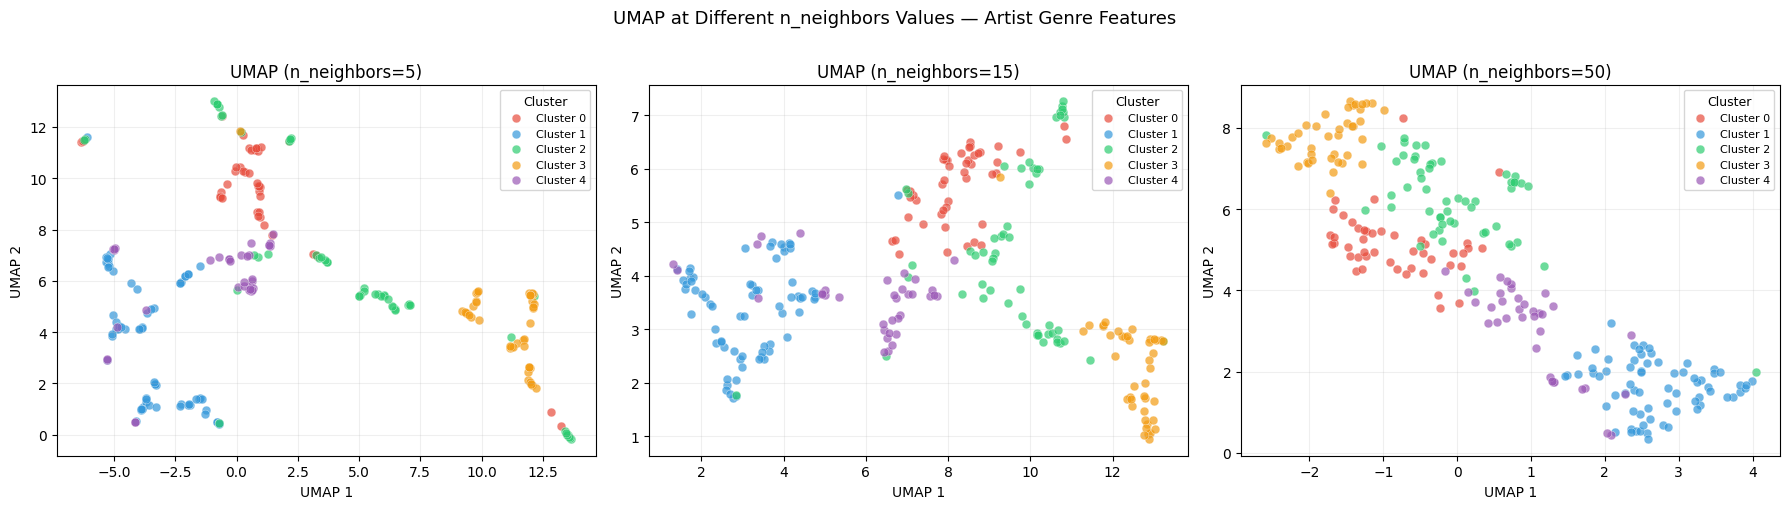


Observations:
  • Small n_neighbors (5):  fragmented, emphasis on local genre structure.
  • n_neighbors=15:         good balance, preserves local and global.
  • Large n_neighbors (50): smoother, global genre structure emphasized.

UMAP vs PCA on this dataset:
  • PCA (20.4% variance): linear projection, loses non-linear structure.
  • UMAP: captures non-linear genre relationships PCA cannot show.
  • UMAP can embed new artists at inference time; t-SNE cannot.


In [446]:
if UMAP_AVAILABLE:
    print("=" * 70)
    print("UMAP: EXPLORING n_neighbors SENSITIVITY")
    print("=" * 70)
    print()
    print("UMAP key parameters:")
    print("  n_neighbors: local vs global tradeoff (5 = local, 50 = global)")
    print("  min_dist:    how tightly to pack points in 2D")
    print("  random_state: always set")
    print()

    neighbor_values = [5, 15, 50]
    umap_results = {}

    for n in neighbor_values:
        print(f"  Fitting UMAP with n_neighbors={n}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=n,
                            min_dist=0.1, random_state=42)
        umap_results[n] = reducer.fit_transform(tfidf_df)
        print("done")

    # Plot all three n_neighbors values
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, n in zip(axes, neighbor_values):
        Z = umap_results[n]
        for cls in range(n_clusters):
            mask = (cluster_labels == cls)
            ax.scatter(
                Z[mask, 0], Z[mask, 1],
                color=colors[cls], label=f'Cluster {cls}',
                alpha=0.7, s=40, edgecolors='white', linewidths=0.3
            )
        ax.set_title(f'UMAP (n_neighbors={n})')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(title='Cluster', fontsize=8, title_fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.suptitle('UMAP at Different n_neighbors Values — Artist Genre Features',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print()
    print("Observations:")
    print("  • Small n_neighbors (5):  fragmented, emphasis on local genre structure.")
    print("  • n_neighbors=15:         good balance, preserves local and global.")
    print("  • Large n_neighbors (50): smoother, global genre structure emphasized.")
    print()
    print("UMAP vs PCA on this dataset:")
    print("  • PCA (20.4% variance): linear projection, loses non-linear structure.")
    print("  • UMAP: captures non-linear genre relationships PCA cannot show.")
    print("  • UMAP can embed new artists at inference time; t-SNE cannot.")

else:
    print("UMAP not available. Install with: pip install umap-learn")
    print("Skipping UMAP section.")

In [456]:
# Align indices before attaching cluster labels
artists_df = artists_df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

# Attach cluster labels to your artist dataframe
artists_df['cluster'] = cluster_labels

# For each cluster: show artists and their top genres
for cls in range(n_clusters):
    subset = artists_df[artists_df['cluster'] == cls]
    print(f"{'=' * 70}")
    print(f"CLUSTER {cls}  ({len(subset)} artists)")
    print(f"{'=' * 70}")
    
    # Artists in this cluster
    print(subset[['artist_name', 'play_count']].sort_values('play_count', ascending=False).to_string(index=False))
    print()
    
    # Dominant genres (mean TF-IDF weight across cluster)
    genre_means = tfidf_df.loc[subset.index].mean().sort_values(ascending=False)
    print("Top genres:")
    print(genre_means.head(8).to_string())
    print()

CLUSTER 0  (46 artists)
                     artist_name  play_count
                         TV Girl        1298
                          Alex G        1244
                        Panchiko         798
             my bloody valentine         669
                          Clairo         649
                     Mac DeMarco         551
                            Cuco         496
                      Weatherday         468
                           Whirr         413
                            Lamp         390
                          Duster         384
                   The Symposium         382
                   Devon Hendryx         382
                     beabadoobee         362
                   Megumi Acorda         362
                  Lily Chou-Chou         336
                     Summer 2000         329
               Car Seat Headrest         318
                        Slowdive         312
                Have a Nice Life         276
              Neutral Milk Hote